In [1]:
import nltk
from nltk.corpus import wordnet,words
from nltk.tokenize import word_tokenize
import random
from transformers import PegasusForConditionalGeneration, PegasusTokenizer
from transformers import pipeline
from transformers import T5Tokenizer
from nltk.tokenize import sent_tokenize,word_tokenize
from nltk import pos_tag
import spacy
from sentence_transformers import SentenceTransformer, util
import Levenshtein
from transformers import BertTokenizer, BertModel
import torch
import re
import torch
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

import numpy as np
from gensim.models import KeyedVectors, FastText
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import BertTokenizer, BertModel
import spacy
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import numpy as np
from sklearn.preprocessing import normalize

nlp = spacy.load("en_core_web_sm")
# Ensure required NLTK corpora are downloaded
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('words')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ALEX\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ALEX\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ALEX\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ALEX\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ALEX\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ALEX\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\ALEX

True

In [2]:
texts = [
    """Today is our dragon boat festival, in our Chinese culture, to celebrate it with all safe and great in our lives.
    Hope you too, to enjoy it as my deepest wishes. Thank your message to show our words to the doctor, as his next contract checking, to all of us.
    I got this message to see the approved message. In fact, I have received the message from the professor, to show me, this, a couple of days ago.
    I am very appreciated the full support of the professor, for our Springer proceedings publication.""",

    """During our final discuss, I told him about the new submission — the one we were waiting since last autumn,
    but the updates was confusing as it not included the full feedback from reviewer or maybe editor?
    Anyway, I believe the team, although bit delay and less communication at recent days, they really tried best for paper and cooperation.
    We should be grateful, I mean all of us, for the acceptance and efforts until the Springer link came finally last week, I think.
    Also, kindly remind me please, if the doctor still plan for the acknowledgments section edit before he sending again.
    Because I didn’t see that part final yet, or maybe I missed, I apologize if so.
    Overall, let us make sure all are safe and celebrate the outcome with strong coffee and future targets."""
]

In [3]:
def simplify_text(text):
    if isinstance(text, list):
        text = " ".join(text)  # Αν κατά λάθος δώσεις λίστα

    doc = nlp(text)
    new_sentences = []

    for sent in doc.sents:
        words = [token.lemma_ if token.pos_ in ["VERB", "NOUN"] else token.text for token in sent]
        cleaned = ' '.join(sorted(set(words), key=words.index))
        new_sentences.append(cleaned.strip().capitalize() + '.')

    return ' '.join(new_sentences)

In [4]:
# Load the T5 paraphraser model from Hugging Face
paraphraser = pipeline("text2text-generation", model="Vamsi/T5_Paraphrase_Paws")

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Device set to use cpu


In [5]:
# Load the Pegasus model for paraphrasing
model_name = "tuner007/pegasus_paraphrase"
tokenizer = PegasusTokenizer.from_pretrained(model_name)
model = PegasusForConditionalGeneration.from_pretrained(model_name)

nlp_p = pipeline("text2text-generation", model=model,tokenizer=tokenizer,truncation=True)

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at tuner007/pegasus_paraphrase and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


In [6]:
All=[]
# Example usage
for i, text in enumerate(texts, 1):
    print(f"Text {i}: {text}")
    print()
    # Synonym paraphrasing
    All.append(simplify_text(text))
    print("Spacy Paraphrase:", All[-1])
    print()

     # T5 Model paraphrasing


    sentences = nltk.sent_tokenize(text)

    paraphrases = []

    for sentence in sentences:
      paraphrase = paraphraser(f"paraphrase: {sentence}", max_length=512, num_return_sequences=3, do_sample=True)
      paraphrases.append(paraphrase[0]['generated_text'])

    paraphrased_text = ' '.join(paraphrases)
    print("Τ5 Paraphrase:", paraphrased_text)
    All.append(paraphrased_text)
    print()


    array1=[]
    array2=[]
    for i in range (0,len(sentences)-1):
        array1.append(nlp_p(sentences[i]))
    
     # Pegasus Model paraphrasing

    for i in range (len(array1)):
          array2.append(array1[i][0]['generated_text'])



    para=' '.join(array2)
    print(f"Pegasus Paraphrase: {para}")
    All.append(para)

    print()

Text 1: Today is our dragon boat festival, in our Chinese culture, to celebrate it with all safe and great in our lives.
    Hope you too, to enjoy it as my deepest wishes. Thank your message to show our words to the doctor, as his next contract checking, to all of us.
    I got this message to see the approved message. In fact, I have received the message from the professor, to show me, this, a couple of days ago.
    I am very appreciated the full support of the professor, for our Springer proceedings publication.

Spacy Paraphrase: Today is our dragon boat festival , in chinese culture to celebrate it with all safe and great life .. Hope you too , to enjoy it as my deepest wish .. Thank your message to show our word the doctor , as his next contract checking all of us .. I get this message to see the approve .. In fact , i have receive the message from professor to show me this a couple of day ago .. I am very appreciated the full support of professor , for our springer proceeding p

In [7]:
All.append(texts[0])
All.append(texts[1])


def levenshtein_similarity(text1, text2):
    # Υπολογισμός της Levenshtein Distance
    lev_distance = Levenshtein.distance(text1, text2)
    # Κανονικοποιημένη ομοιότητα (0 - 1)
    similarity = 1 - lev_distance / max(len(text1), len(text2))
    return similarity

k_model=["Spacy Paraphrase","T5 Paraphrase","Pegasus Paraphrase"]

In [8]:
texts = [
    """Today is our Dragon Boat Festival — a special occasion in Chinese culture where we celebrate with wishes for safety, prosperity, and good health.
I hope you also enjoy this day, and I send you my warmest wishes.
Thank you for your message and for conveying our words to the doctor regarding his upcoming contract review — it means a lot to all of us.
I saw the approved message earlier, and in fact, I had already received a similar message from the professor a few days ago.
I truly appreciate the professor’s continued support, especially for our Springer proceedings publication.""",

    """During our final discussion, I mentioned the new submission — the one we’ve been waiting for since last autumn.
However, the latest update was a bit unclear, as it didn’t seem to include the full feedback from the reviewer, or perhaps the editor?  
In any case, I truly believe the team has done their best on the paper and collaboration, despite some recent delays and limited communication.
We should all be grateful for the acceptance and the efforts that led us to the final Springer link — which I believe came through just last week.
Also, could you kindly remind me whether the doctor still plans to edit the acknowledgments section before resubmitting?
I haven't seen the final version of that part yet — or I may have missed it, and if so, my apologies.
Overall, let’s make sure everything is in place and take a moment to celebrate this achievement — perhaps with a strong coffee and a focus on future goals."""
]



In [9]:
def simple_tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

originals, paraphrases=[],[]


originals = [texts[0], texts[1]]
paraphrases = [All[0], All[1], All[2], All[3], All[4], All[5]]

w2v = Word2Vec([t.split() for t in originals+paraphrases], vector_size=100, window=5, min_count=1)


ft = FastText(vector_size=100, window=3, min_count=1)
ft.build_vocab([t.split() for t in originals+paraphrases])
ft.train([t.split() for t in originals+paraphrases], total_examples=len(originals+paraphrases), epochs=5)
#   3.4 BERT embeddings
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')


def get_bert_emb(text):
    toks = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        out = bert_model(**toks)
    return out.last_hidden_state.mean(dim=1).cpu().numpy()[0]

# Συνάρτηση μέσου όρου embeddings λέξεων για word-level μεθόδους


def mean_embedding(tokens, model, normalize_embeddings=True, min_word_count=1):
    """
    Υπολογίζει τη μέση τιμή των word embeddings για μία λίστα λέξεων.
    """
    valid_embeddings = []
    found_words = []  # Λίστα για τις λέξεις που βρέθηκαν στο μοντέλο

    for token in tokens:
        if token in model:
            valid_embeddings.append(model[token])
            found_words.append(token)  # Αποθηκεύουμε τις λέξεις που βρέθηκαν στο μοντέλο

    if not valid_embeddings:

        return np.zeros(model.vector_size)

    # Μέσος όρος των embeddings
    mean_vector = np.mean(valid_embeddings, axis=0)

    # Κανονικοποίηση, αν χρειάζεται
    if normalize_embeddings:
        mean_vector = normalize(mean_vector.reshape(1, -1)).flatten()




    return mean_vector



In [10]:
def preprocess(text):
    doc = nlp(text.lower())
    tokens = [t.lemma_ for t in doc if not t.is_stop and not t.is_punct]
    if not tokens:
        tokens = [t.text for t in doc if not t.is_punct]
    return tokens


all_texts = [" ".join(preprocess(t)) for t in originals + paraphrases]
tfidf = TfidfVectorizer()
tfidf.fit(all_texts)
vocab = tfidf.get_feature_names_out()

corpus = [preprocess(t) for t in originals + paraphrases]

w2v = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=1)


In [11]:
# Εκπαίδευση FastText
ft = FastText(vector_size=100, window=3, min_count=1)
ft.build_vocab(corpus)
ft.train(corpus, total_examples=len(corpus), epochs=5)


# 4. Υπολογισμός cosine similarity
methods = {}
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

for name, embed_func in [
    ("Word2Vec", lambda toks: mean_embedding(toks, w2v.wv)),
    ("FastText", lambda toks: mean_embedding(toks, ft.wv)),
    ("BERT", lambda text: get_bert_emb(" ".join(text)))
]:
    sims = []
    for i, orig in enumerate(originals):
        for j in range(3):
            para = paraphrases[i * 3 + j]
            emb_o = embed_func(preprocess(orig))
            emb_p = embed_func(preprocess(para))
            sim = cosine_similarity([emb_o], [emb_p])[0][0]
            sims.append(sim)
    methods[name] = sims

# Similarity
sbert_sims = []
for i, orig in enumerate(originals):
    for j in range(3):
        para = paraphrases[i * 3 + j]
        emb1 = sbert_model.encode(preprocess(orig), convert_to_tensor=True)
        emb2 = sbert_model.encode(preprocess(para), convert_to_tensor=True)
        sim = util.cos_sim(emb1, emb2).cpu().numpy()[0][0]
        sbert_sims.append(sim)
methods["Cosine"] = sbert_sims

# Levenshtein Distance
lev_sims = []
for i, orig in enumerate(originals):
    for j in range(3):
        para = paraphrases[i * 3 + j]
        lev = levenshtein_similarity(" ".join(preprocess(orig)), " ".join(preprocess(para)))
        lev_sims.append(lev)
methods["Levenshtein"] = lev_sims
# 5. Παρουσίαση Αποτελεσμάτων


print()
print()

for name, sims in methods.items():
    print()
    for i, sim in enumerate(sims, 1):

        if i <= 3:
            print(f"{name}  Similarity (Text1 vs {k_model[i-1]} 1):  {sim:.4f}")
        else:
            if i==4:
                print()
            model_index = (i - 4) % 3  # για να ξεκινάει πάλι από 0
            print(f"{name} Similarity (Text2 vs {k_model[model_index]} 2):  {sim:.4f}")





Word2Vec  Similarity (Text1 vs Spacy Paraphrase 1):  0.6300
Word2Vec  Similarity (Text1 vs T5 Paraphrase 1):  0.6443
Word2Vec  Similarity (Text1 vs Pegasus Paraphrase 1):  0.5856

Word2Vec Similarity (Text2 vs Spacy Paraphrase 2):  0.6570
Word2Vec Similarity (Text2 vs T5 Paraphrase 2):  0.6139
Word2Vec Similarity (Text2 vs Pegasus Paraphrase 2):  0.6213

FastText  Similarity (Text1 vs Spacy Paraphrase 1):  0.4835
FastText  Similarity (Text1 vs T5 Paraphrase 1):  0.4949
FastText  Similarity (Text1 vs Pegasus Paraphrase 1):  0.3839

FastText Similarity (Text2 vs Spacy Paraphrase 2):  0.4633
FastText Similarity (Text2 vs T5 Paraphrase 2):  0.4430
FastText Similarity (Text2 vs Pegasus Paraphrase 2):  0.4223

BERT  Similarity (Text1 vs Spacy Paraphrase 1):  0.9595
BERT  Similarity (Text1 vs T5 Paraphrase 1):  0.9599
BERT  Similarity (Text1 vs Pegasus Paraphrase 1):  0.9079

BERT Similarity (Text2 vs Spacy Paraphrase 2):  0.9706
BERT Similarity (Text2 vs T5 Paraphrase 2):  0.9684
BERT Sim

2
8
8
8


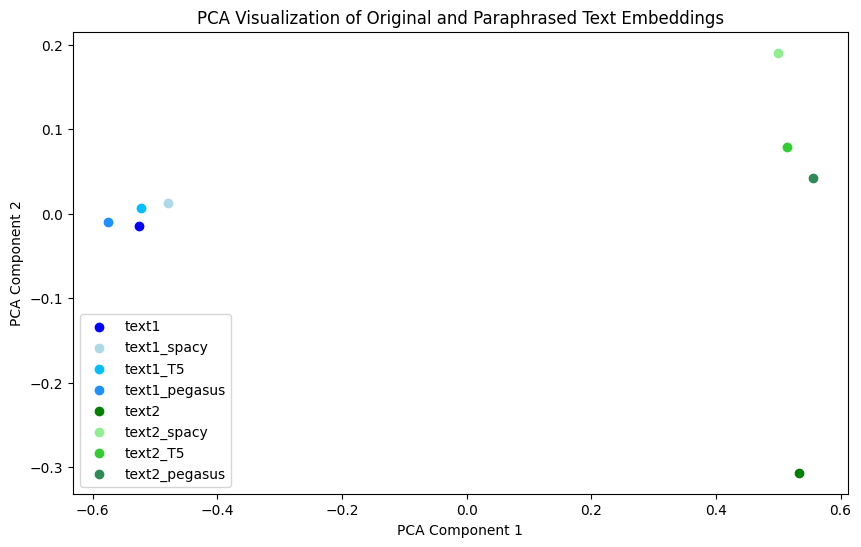

In [16]:

all_texts = [texts[0]]+All[:3]+[texts[1]]+All[3:6]

labels = [
    'text1',
    'text1_spacy', 'text1_T5', 'text1_pegasus',
    'text2',
    'text2_spacy', 'text2_T5', 'text2_pegasus'
]





# Φόρτωση μοντέλου
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(all_texts)

# PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)  # << Εδώ το pca_result ήταν σωστό αλλά μετά καλούσες "reduced"


label_colors = {
    'text1': 'blue',
    'text1_spacy': 'lightblue',
    'text1_T5': 'deepskyblue',
    'text1_pegasus': 'dodgerblue',
    'text2': 'green',
    'text2_spacy': 'lightgreen',
    'text2_T5': 'limegreen',
    'text2_pegasus': 'seagreen'
}
colors = [label_colors[label] for label in labels]

# Οπτικοποίηση
plt.figure(figsize=(10, 6))

for i, (x, y) in enumerate(reduced):
    plt.scatter(x, y, color=colors[i], label=labels[i])
plt.legend()
plt.title("PCA Visualization of Original and Paraphrased Text Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()